# Hybrid Quantum-Classical Neural Network for MNIST Classification

## 1. Introduction
This notebook demonstrates the implementation of a **Hybrid Quantum-Classical Neural Network (HQCNN)**. This architecture bridges classical deep learning with quantum computing by combining **Convolutional Neural Networks (CNNs)** for high-level feature extraction with **Quantum Neural Networks (QNNs)** for classification.

<p align="center">
  <img src="pytorchConnQiskit.jpg" alt="Hybrid Integration Workflow" width="80%"/>
</p>

### Why Hybrid?
* **Classical Layers:** Use `Conv2d` layers to downsample high-dimensional image data (28x28 pixels) into a low-dimensional vector (e.g., 2 features) suitable for the quantum bottleneck.
* **Quantum Layers:** A Qiskit-based QNN processes these features. Quantum circuits can potentially explore higher-dimensional feature spaces (Hilbert space) that are computationally difficult for classical networks to navigate.
* **Integration:** We use the `TorchConnector` from `qiskit_machine_learning` to allow the quantum circuit to behave like a standard PyTorch module, enabling seamless backpropagation and optimization across the entire hybrid pipeline.

In [8]:
# ============================================================================
# SETUP AND IMPORTS
# ============================================================================

# Standard libraries
import numpy as np
import matplotlib.pyplot as plt

# PyTorch imports
import torch
from torch import cat, no_grad, manual_seed
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.optim as optim
from torch.nn import (
    Module, Conv2d, Linear, Dropout2d, NLLLoss, 
    MaxPool2d, Flatten, Sequential, ReLU
)
import torch.nn.functional as F

# Qiskit imports
from qiskit import QuantumCircuit
from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_algorithms.utils import algorithm_globals
from qiskit.primitives import StatevectorEstimator as Estimator

# Fix seeds for reproducibility
algorithm_globals.random_seed = 42

In [5]:
# ============================================================================
# DATA PREPARATION (MNIST 0, 1, 2)
# ============================================================================

batch_size = 1
n_samples = 100  # Samples per class

# Load MNIST training data
X_train = datasets.MNIST(
    root="./data", train=True, download=True, transform=transforms.Compose([transforms.ToTensor()])
)

# Filter for labels 0, 1, and 2
idx = np.append(
    np.where(X_train.targets == 0)[0][:n_samples], 
    np.append(np.where(X_train.targets == 1)[0][:n_samples], 
              np.where(X_train.targets == 2)[0][:n_samples])
)
X_train.data = X_train.data[idx]
X_train.targets = X_train.targets[idx]

train_loader = DataLoader(X_train, batch_size=batch_size, shuffle=True)

# Load and filter MNIST test data
n_test_samples = 50
X_test = datasets.MNIST(
    root="./data", train=False, download=True, transform=transforms.Compose([transforms.ToTensor()])
)

idx_test = np.append(
    np.where(X_test.targets == 0)[0][:n_test_samples], 
    np.append(np.where(X_test.targets == 1)[0][:n_test_samples], 
              np.where(X_test.targets == 2)[0][:n_test_samples])
)
X_test.data = X_test.data[idx_test]
X_test.targets = X_test.targets[idx_test]

test_loader = DataLoader(X_test, batch_size=batch_size, shuffle=True)

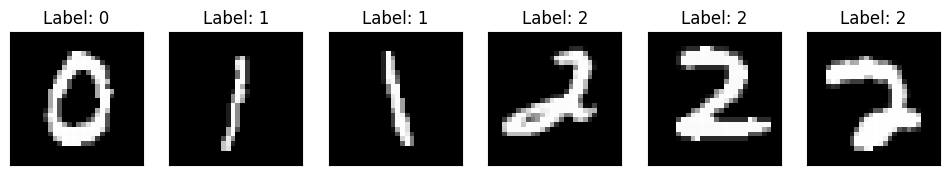

In [6]:
# Visualize samples
n_samples_show = 6
data_iter = iter(train_loader)
fig, axes = plt.subplots(nrows=1, ncols=n_samples_show, figsize=(12, 3))
for i in range(n_samples_show):
    images, targets = next(data_iter)
    axes[i].imshow(images[0, 0].numpy().squeeze(), cmap="gray")
    axes[i].set_xticks([]); axes[i].set_yticks([])
    axes[i].set_title(f"Label: {targets[0].item()}")

In [9]:
# ============================================================================
# QUANTUM CIRCUIT DEFINITION
# ============================================================================

def create_qnn():
    # Use 2 qubits to process 2 features from the classical CNN
    feature_map = zz_feature_map(2)
    ansatz = real_amplitudes(2, reps=1)
    
    qc = QuantumCircuit(2)
    qc.compose(feature_map, inplace=True)
    qc.compose(ansatz, inplace=True)
    
    # Define the QNN using the Estimator primitive
    qnn = EstimatorQNN(
        circuit=qc,
        input_params=feature_map.parameters,
        weight_params=ansatz.parameters,
        input_gradients=True,
        estimator=Estimator()
    )
    return qnn

qnn_instance = create_qnn()

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


In [10]:
# ============================================================================
# HYBRID CLASSICAL-QUANTUM MODEL
# ============================================================================

class Net(Module):
    def __init__(self, qnn):
        super().__init__()
        self.conv1 = Conv2d(1, 2, kernel_size=5)
        self.conv2 = Conv2d(2, 16, kernel_size=5)
        self.dropout = Dropout2d()
        self.fc1 = Linear(256, 64)
        self.fc2 = Linear(64, 2)          # QNN input features (2 qubits)
        self.qnn = TorchConnector(qnn)    # The Quantum Layer
        self.fc3 = Linear(1, 3)           # Map QNN output to 3 classes (0, 1, 2)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = self.dropout(x)
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        x = self.qnn(x)                   # Forward pass through Quantum Circuit
        x = self.fc3(x)                   # Final linear layer for 3-class logit
        return F.log_softmax(x, dim=1)    # Log-Softmax for NLLLoss

model = Net(qnn_instance)

Training [10%]	Loss: 1.1124
Training [20%]	Loss: 0.8692
Training [30%]	Loss: 0.7528
Training [40%]	Loss: 0.6780
Training [50%]	Loss: 0.6310
Training [60%]	Loss: 0.5996
Training [70%]	Loss: 0.5695
Training [80%]	Loss: 0.5545
Training [90%]	Loss: 0.5501
Training [100%]	Loss: 0.5275


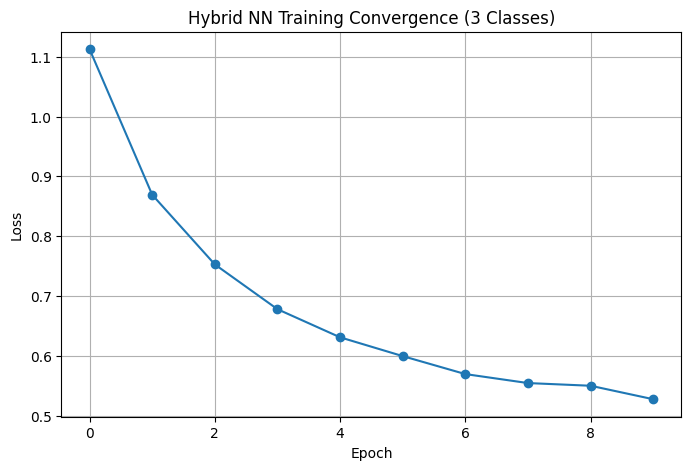

In [11]:
# ============================================================================
# TRAINING CONFIGURATION AND LOOP
# ============================================================================

optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_func = NLLLoss()

epochs = 10
loss_list = []

model.train()
for epoch in range(epochs):
    total_loss = []
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad(set_to_none=True)
        output = model(data)
        loss = loss_func(output, target)
        loss.backward()
        optimizer.step()
        total_loss.append(loss.item())
    
    loss_list.append(sum(total_loss) / len(total_loss))
    print(f"Training [{100.0 * (epoch + 1) / epochs:.0f}%]\tLoss: {loss_list[-1]:.4f}")

# Plot training convergence
plt.figure(figsize=(8, 5))
plt.plot(loss_list, marker='o', color='tab:blue')
plt.title("Hybrid NN Training Convergence (3 Classes)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [13]:
# ============================================================================
# MODEL EVALUATION
# ============================================================================

model.eval()
test_loss = []
correct = 0

with no_grad():
    for data, target in test_loader:
        output = model(data)
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        loss = loss_func(output, target)
        test_loss.append(loss.item())

print(f"Test Accuracy: {100. * correct / len(test_loader.dataset):.2f}%")
print(f"Average Test Loss: {sum(test_loss)/len(test_loss):.4f}")

Test Accuracy: 73.33%
Average Test Loss: 0.5303


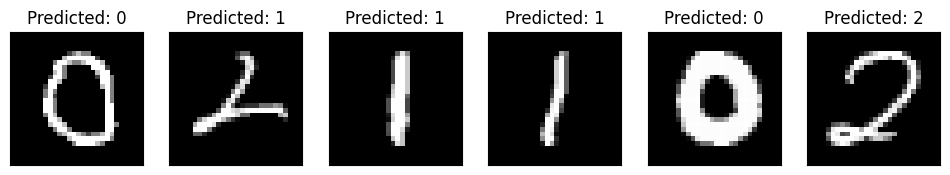

In [28]:
# Visualize Predictions
n_samples_show = 6
fig, axes = plt.subplots(nrows=1, ncols=n_samples_show, figsize=(12, 3))
for i, (data, target) in enumerate(test_loader):
    if i == n_samples_show: break
    output = model(data)
    pred = output.argmax(dim=1, keepdim=True)
    axes[i].imshow(data[0].numpy().squeeze(), cmap="gray")
    axes[i].set_xticks([]); axes[i].set_yticks([])
    axes[i].set_title(f"Predicted: {pred.item()}")

# Conclusions

* **Successful Integration:** We successfully built a pipeline where classical CNN layers perform feature compression, feeding into a 2-qubit QNN, now expanded to classify three digits (0, 1, and 2).
* **Backpropagation:** Using `TorchConnector`, PyTorch was able to compute gradients through the quantum circuit, allowing the classical layers to "learn" how to best format data for the quantum layer.
* **Multi-Class Handling:** By adding a final classical linear layer after the QNN, we can map the single-value expectation output of the quantum circuit into a multi-dimensional logit space for 3-class classification.